In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import camb
import math
from camb import model, initialpower
print('Using CAMB %s'%(camb.__version__))
plots_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/plots/"
data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Using CAMB 1.5.9
Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data


## Load 

In [4]:
Tcmb = 2.7255
CF = (Tcmb*10**6)**2

#Converting the c_ls^TT to Dls
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Conerting Dls to the c_ls^TT
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(CF*l[i]*l[i]+1)*DlTT[i] for i in range(len(l))]
    return ClTT

Filename: ./simulated_data/simulated_maps/polarization/cmb_pol_map_T_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


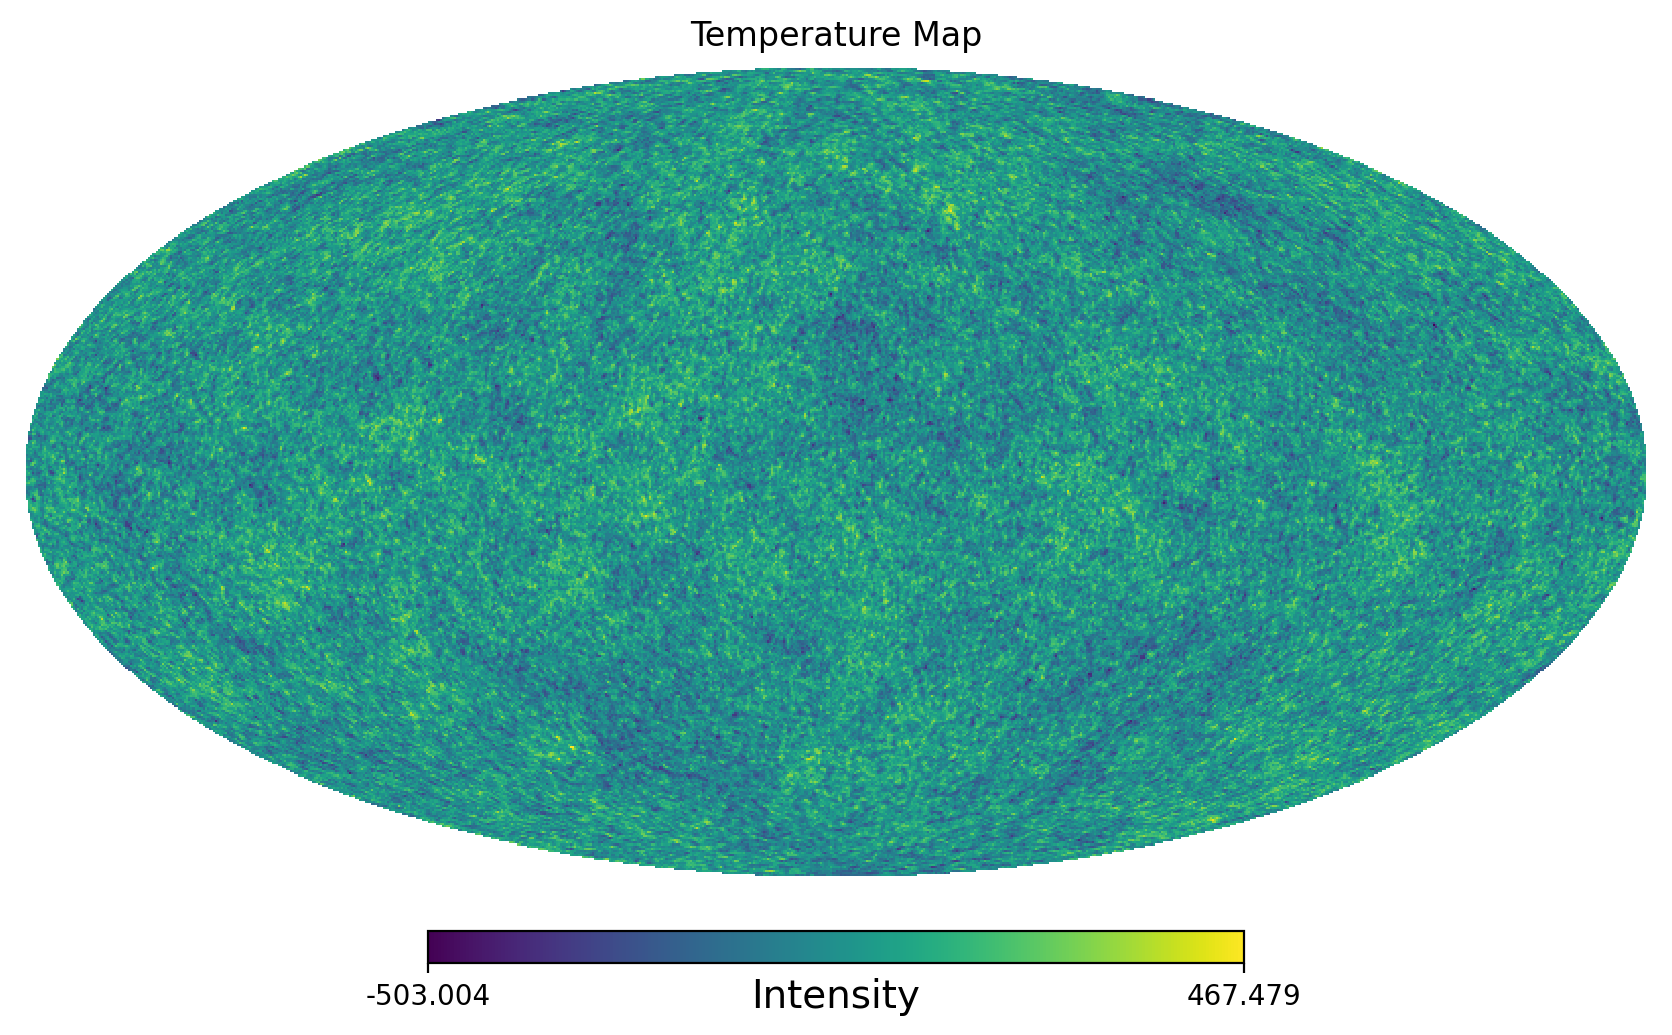

Filename: ./simulated_data/simulated_maps/polarization/cmb_pol_map_T_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


In [3]:
import healpy as hp
from SkySimulation import read_map
path_lcdm = "./simulated_data/simulated_maps/polarization/"
map_temp_data = read_map(path_lcdm + 'cmb_pol_map_T_0.fits')
hp.mollview(map_temp_data, title="Temperature Map", unit="Intensity")
plt.show()
path_feature = "./simulated_data/simulated_maps/polarization/"
map_feature_data = read_map(path_feature + 'cmb_pol_map_T_feature_0.fits')
#hp.mollview(map_feature_data, title="Feature Map", unit="Intensity")
#plt.show()

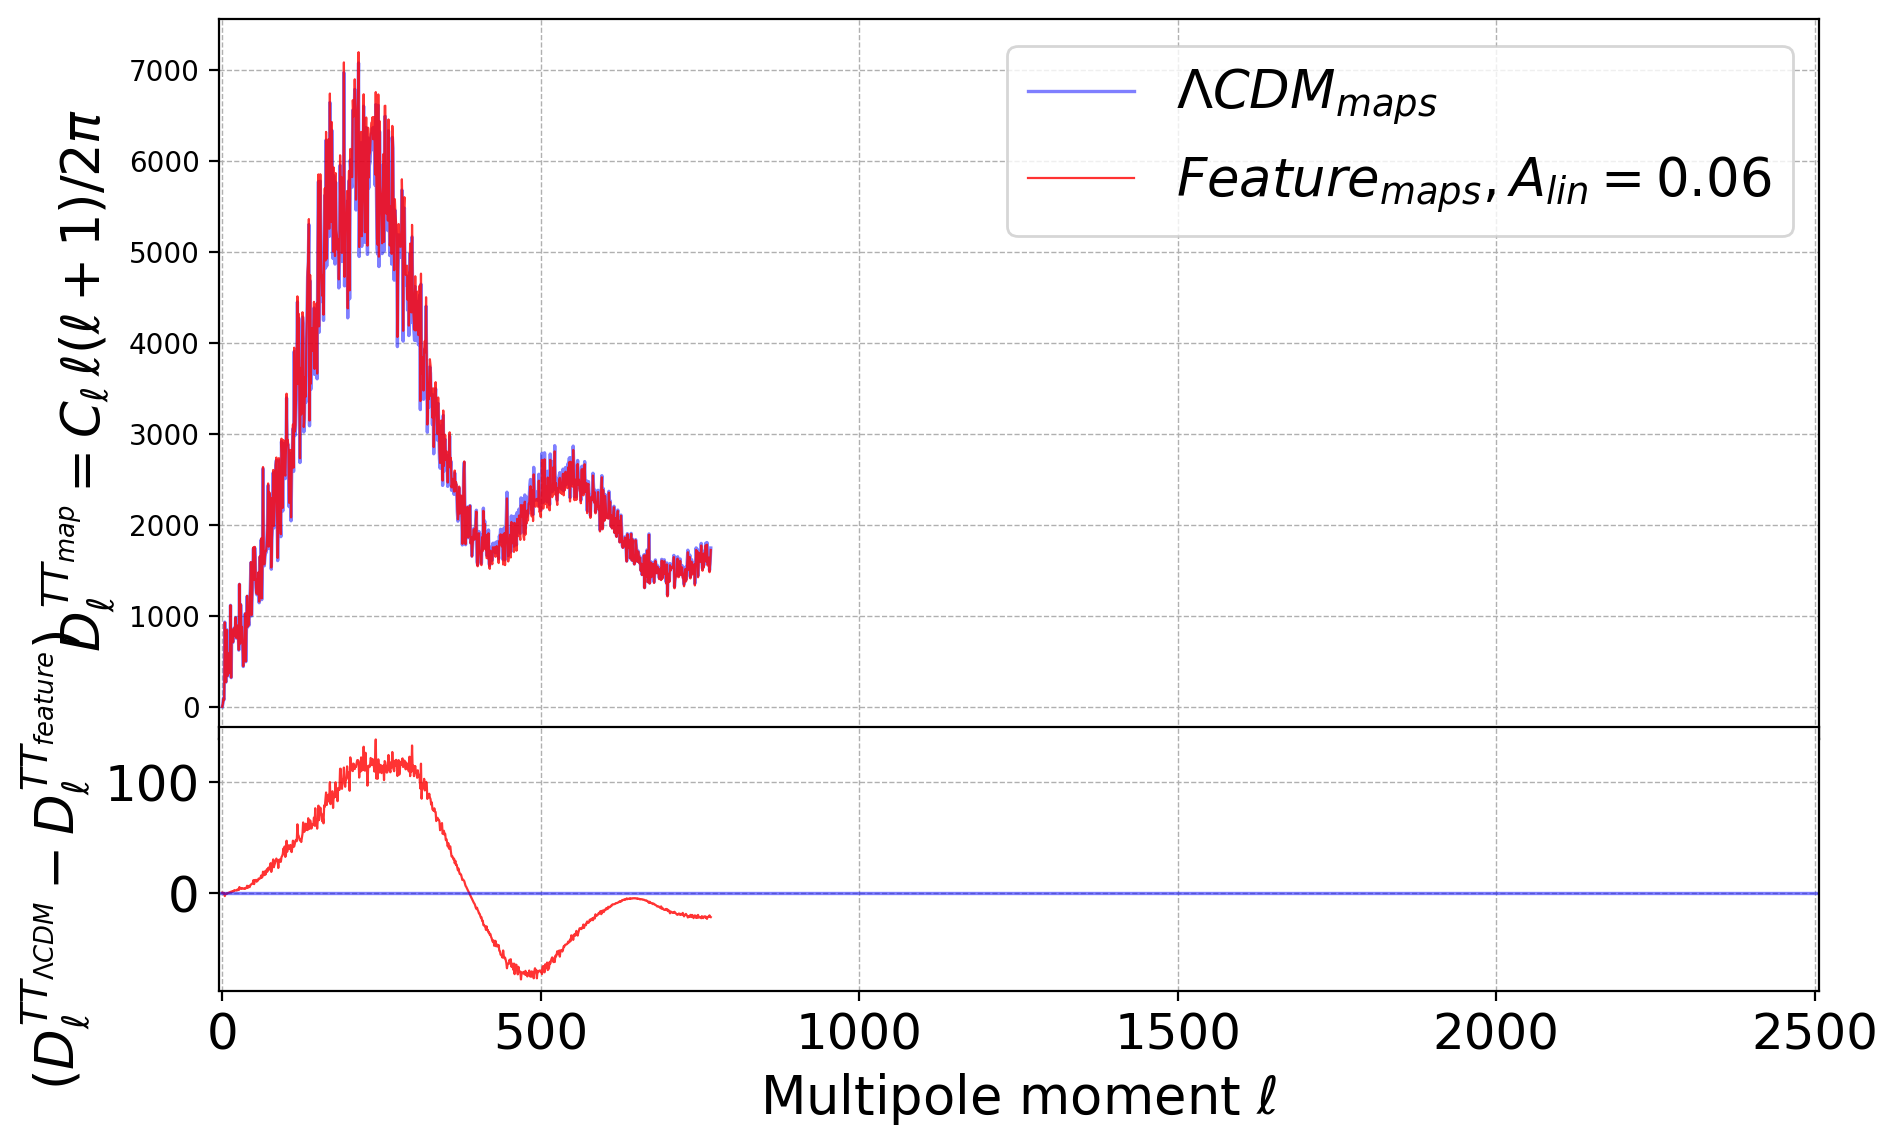

In [25]:
#Compute the power spectra
cl_tt_map_feature = hp.anafast(map_feature_data , pol=True)
cl_tt_map_lcdm = hp.anafast(map_temp_data , pol=True)
fsize = 19
ell = np.arange(2507)
#lmax = len(cl_tt_map)
lmax = len(cl_tt_map_feature)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_lcdm)[:lmax], 
            label='$\Lambda CDM_{maps}$', alpha=0.5, color='blue', linewidth=1.2)
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_feature)[:lmax], 
            label='$Feature_{maps}, A_{lin}=0.06$', alpha=0.8, linestyle='-', linewidth=0.8, color='red')
#frame1.plot(ell, Power_spectra_normal[1], 
            #label='$\Lambda CDM$', color='gray')
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$', fontsize=fsize)
frame1.set_xlim(-5, 2507)
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend(fontsize=fsize)
 
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
#diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - Power_spectra_normal[1][:lmax])
#diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - Power_spectra_normal[1][:lmax])
diff1 = np.array(Dls(ell[:lmax], cl_tt_map_feature)) - np.array(Dls(ell[:lmax], cl_tt_map_lcdm))
#frame2.plot(ell[:lmax], diff2, color='blue', alpha=0.5)
frame2.plot(ell[:lmax], diff1, alpha=0.8, color='red', linestyle='-', linewidth=0.8)
frame2.axhline(y=0, alpha=0.5, color='blue', linewidth=1.2)
frame2.set_xlabel(r'Multipole moment $\ell$', fontsize=19)
frame2.set_ylabel(r'$(D_\ell^{TT_{\Lambda CDM}} - D_\ell^{TT_{feature}})$', fontsize=fsize)
frame2.tick_params(axis='x', labelsize=18)
frame2.tick_params(axis='y', labelsize=18)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(plots_directory + 'Recoverable_TT_maps.png', dpi=300)
plt.show()
#The plot looks that way, becuse we're taking the extreme values of the simulated data. In principle, the difference [-20,20]

In [6]:
map_Q_feature_data = read_map(path_feature + './cmb_pol_map_Q_0.fits')
map_Q_data = read_map(path_feature + './cmb_pol_map_Q_feature_0.fits')
map_U_feature_data = read_map(path_feature + './cmb_pol_map_U_0.fits')
map_U_data = read_map(path_feature + './cmb_pol_map_U_feature_0.fits')

Filename: ./simulated_data/simulated_maps/polarization/./cmb_pol_map_Q_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_data/simulated_maps/polarization/./cmb_pol_map_Q_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_data/simulated_maps/polarization/./cmb_pol_map_U_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_data/simulated_maps/polarization/./cmb_pol_map_U_feature_0.fits
No.   

NSIDE: 256


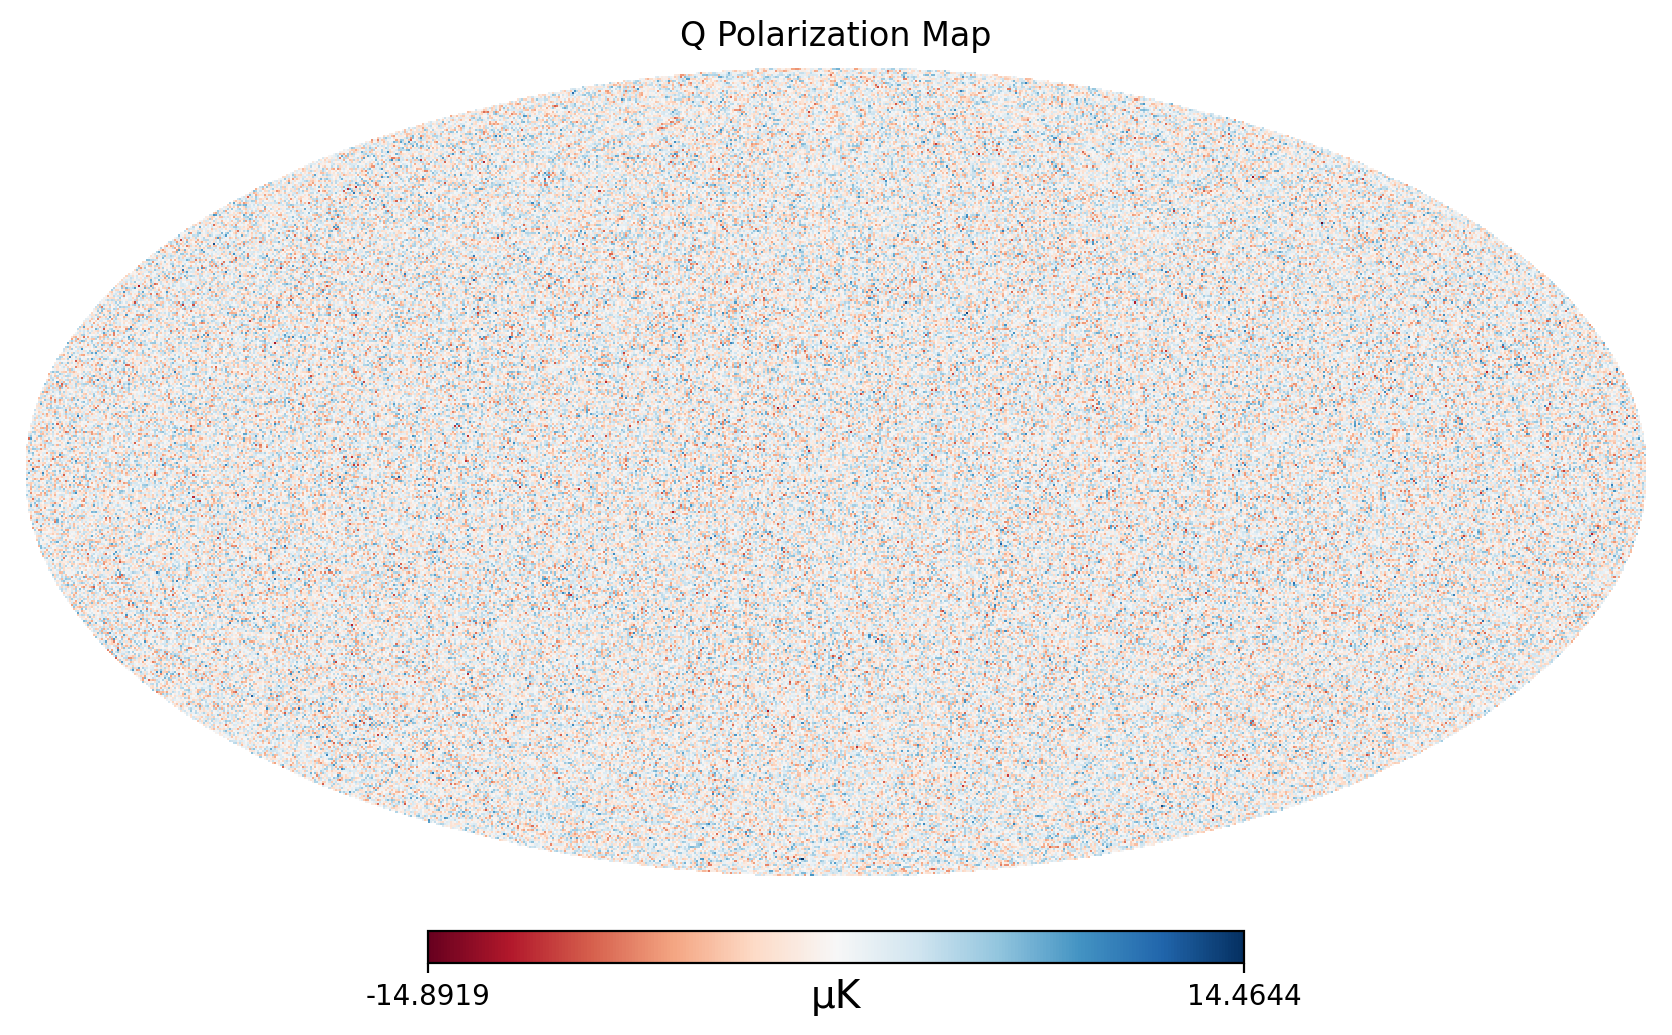

In [7]:
#Visualize the Q map
nside = hp.npix2nside(len(map_Q_data))
print(f"NSIDE: {nside}")

hp.mollview(map_Q_data, title="Q Polarization Map", unit="μK", cmap="RdBu")
plt.show()

NSIDE: 256


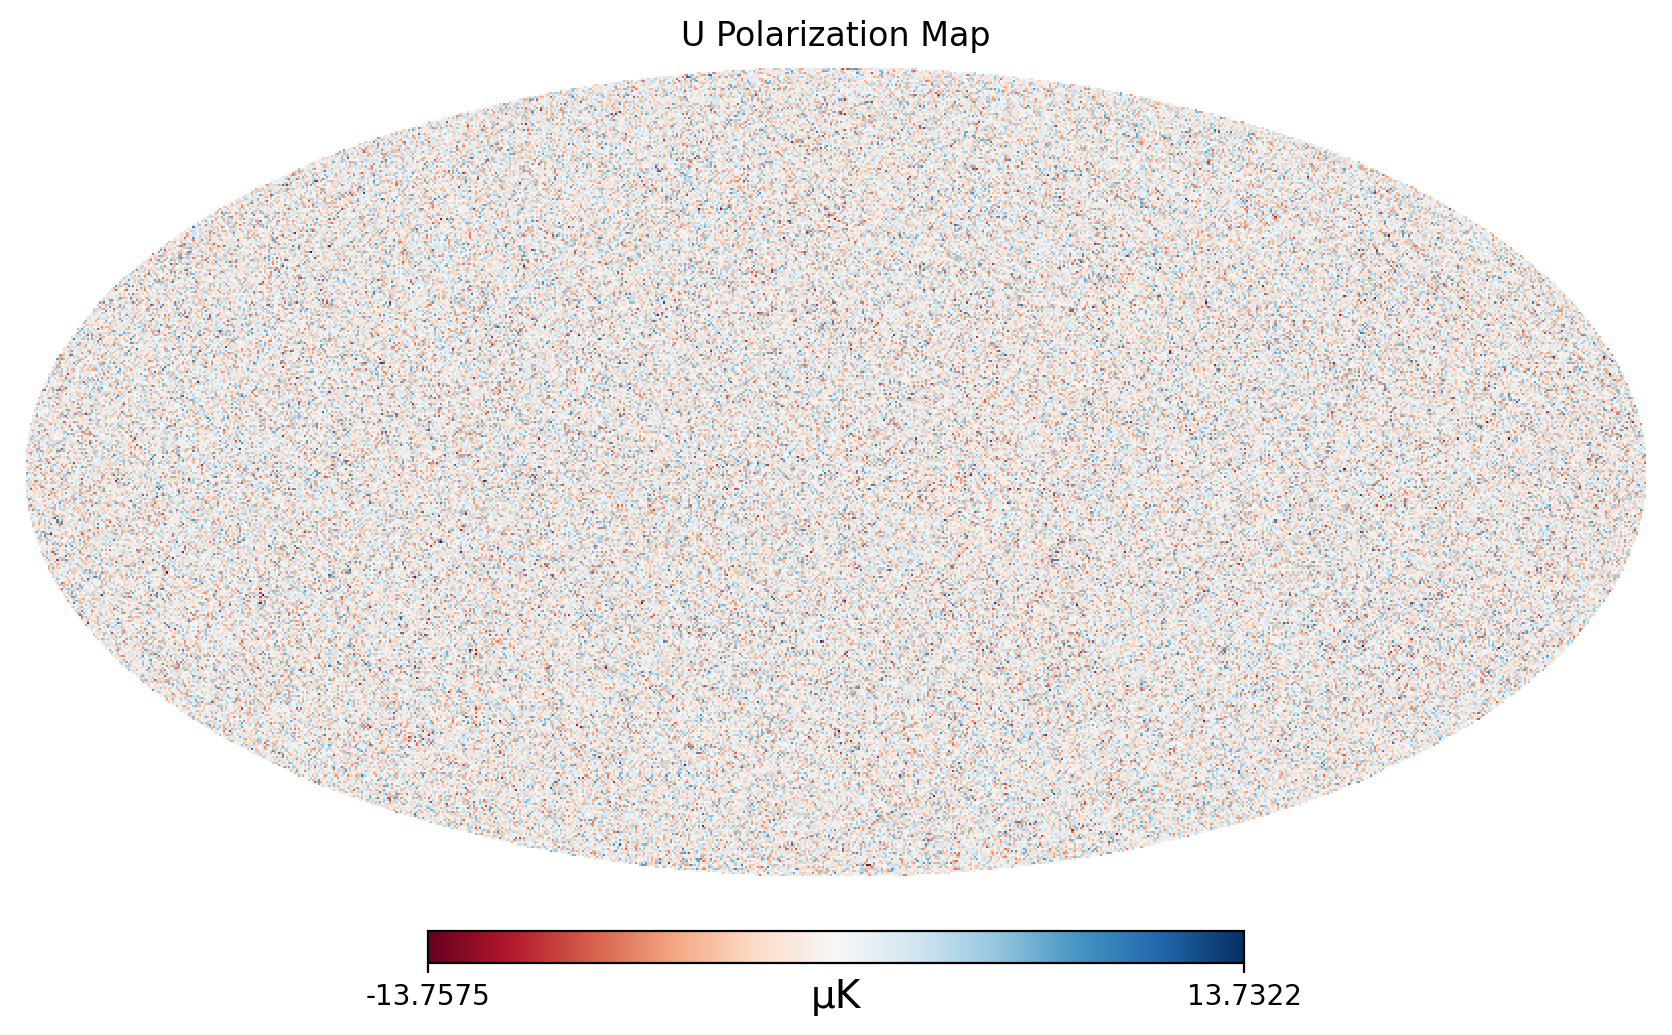

In [8]:
#Visualize the Q map
nside = hp.npix2nside(len(map_U_data))
print(f"NSIDE: {nside}")

hp.mollview(map_U_data, title="U Polarization Map", unit="μK", cmap="RdBu")
plt.show()

In [11]:
# Combine maps into an input list
maps = [map_temp_data, map_Q_data, map_U_data]
maps_feature = [map_feature_data, map_Q_feature_data, map_U_feature_data]

# Compute the power spectra
cl_tt_map, cl_ee_map_sm, cl_bb_map_sm, cl_te_map_sm, cl_eb_map_sm, cl_tb_map_sm = hp.anafast(maps, pol=True)
cl_tt_map_f, cl_ee_map_sm_f, cl_bb_map_sm_f, cl_te_map_sm_f, cl_eb_map_sm_f, cl_tb_map_sm_f = hp.anafast(maps_feature, pol=True)

In [ ]:
from SkySimulation import deconvolve_gaussian_beam

ell = np.arange(2507)
cl_te_map = deconvolve_gaussian_beam(ell, cl_te_map_sm, fwhm_arcmin=5.0)
cl_ee_map = deconvolve_gaussian_beam(ell, cl_ee_map_sm, fwhm_arcmin=5.0)
cl_te_map_f = deconvolve_gaussian_beam(ell, cl_te_map_sm_f, fwhm_arcmin=5.0)
cl_ee_map_f = deconvolve_gaussian_beam(ell, cl_ee_map_sm_f, fwhm_arcmin=5.0)

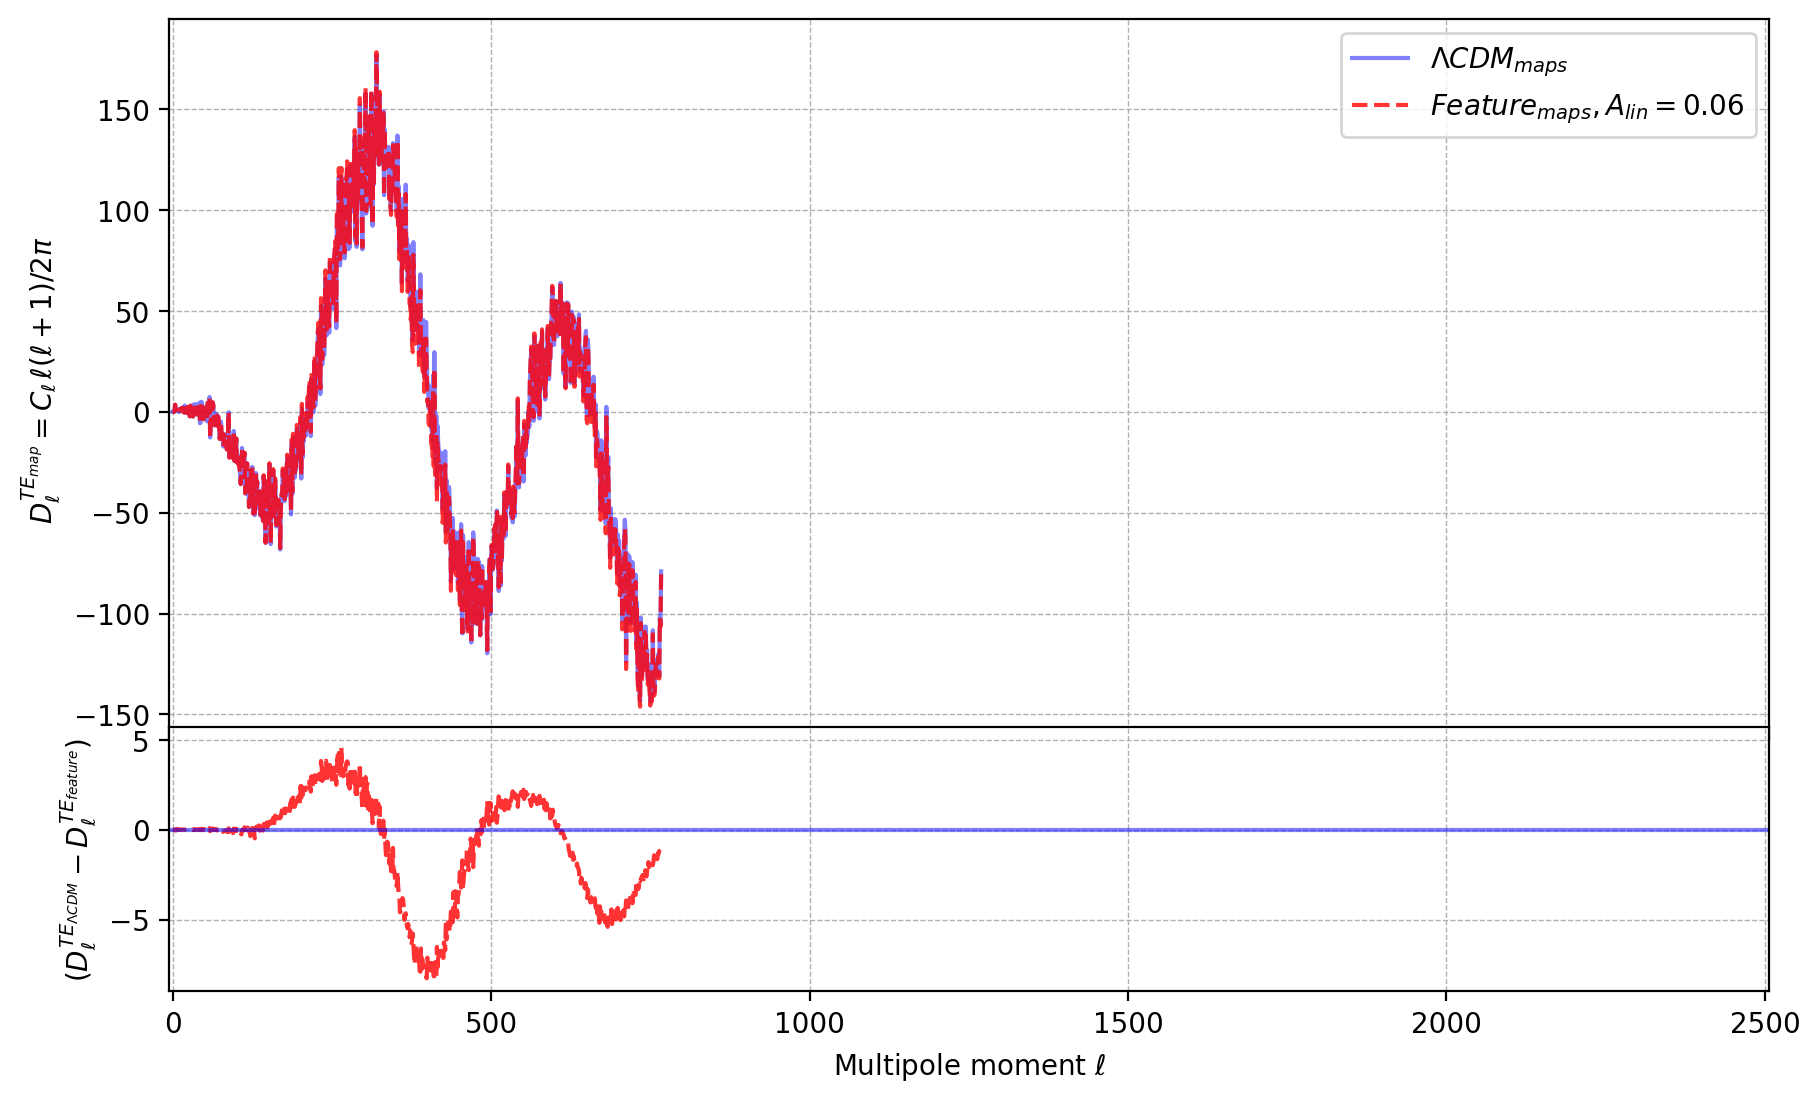

In [ ]:
lmax = len(cl_te_map_f)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_te_map)[:lmax], 
            label='$\Lambda CDM_{maps}$', alpha=0.5, color='blue')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_te_map_f)[:lmax], 
            label='$Feature_{maps}, A_{lin}=0.06$', alpha=0.8, color='red', linestyle='--')
#frame1.plot(ell, Power_spectra_normal[1], 
            #label='$\Lambda CDM$', color='gray')
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TE_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, 2507)
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()
 
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
#diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - Power_spectra_normal[1][:lmax])
#diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - Power_spectra_normal[1][:lmax])
diff1 = np.array(Dls(ell[:lmax], cl_te_map_f)) - np.array(Dls(ell[:lmax], cl_te_map))
#frame2.plot(ell[:lmax], diff2, color='blue', alpha=0.5)
frame2.plot(ell[:lmax], diff1, alpha=0.8, color='red', linestyle='--')
frame2.axhline(y=0, alpha=0.5, color='blue')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylim(-9,5.7)
frame2.set_ylabel(r'$(D_\ell^{TE_{\Lambda CDM}} - D_\ell^{TE_{feature}})$')
frame2.tick_params(axis='x', labelsize=10)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(plots_directory + 'Recoverable_TE_maps.png', dpi=300)

plt.show()

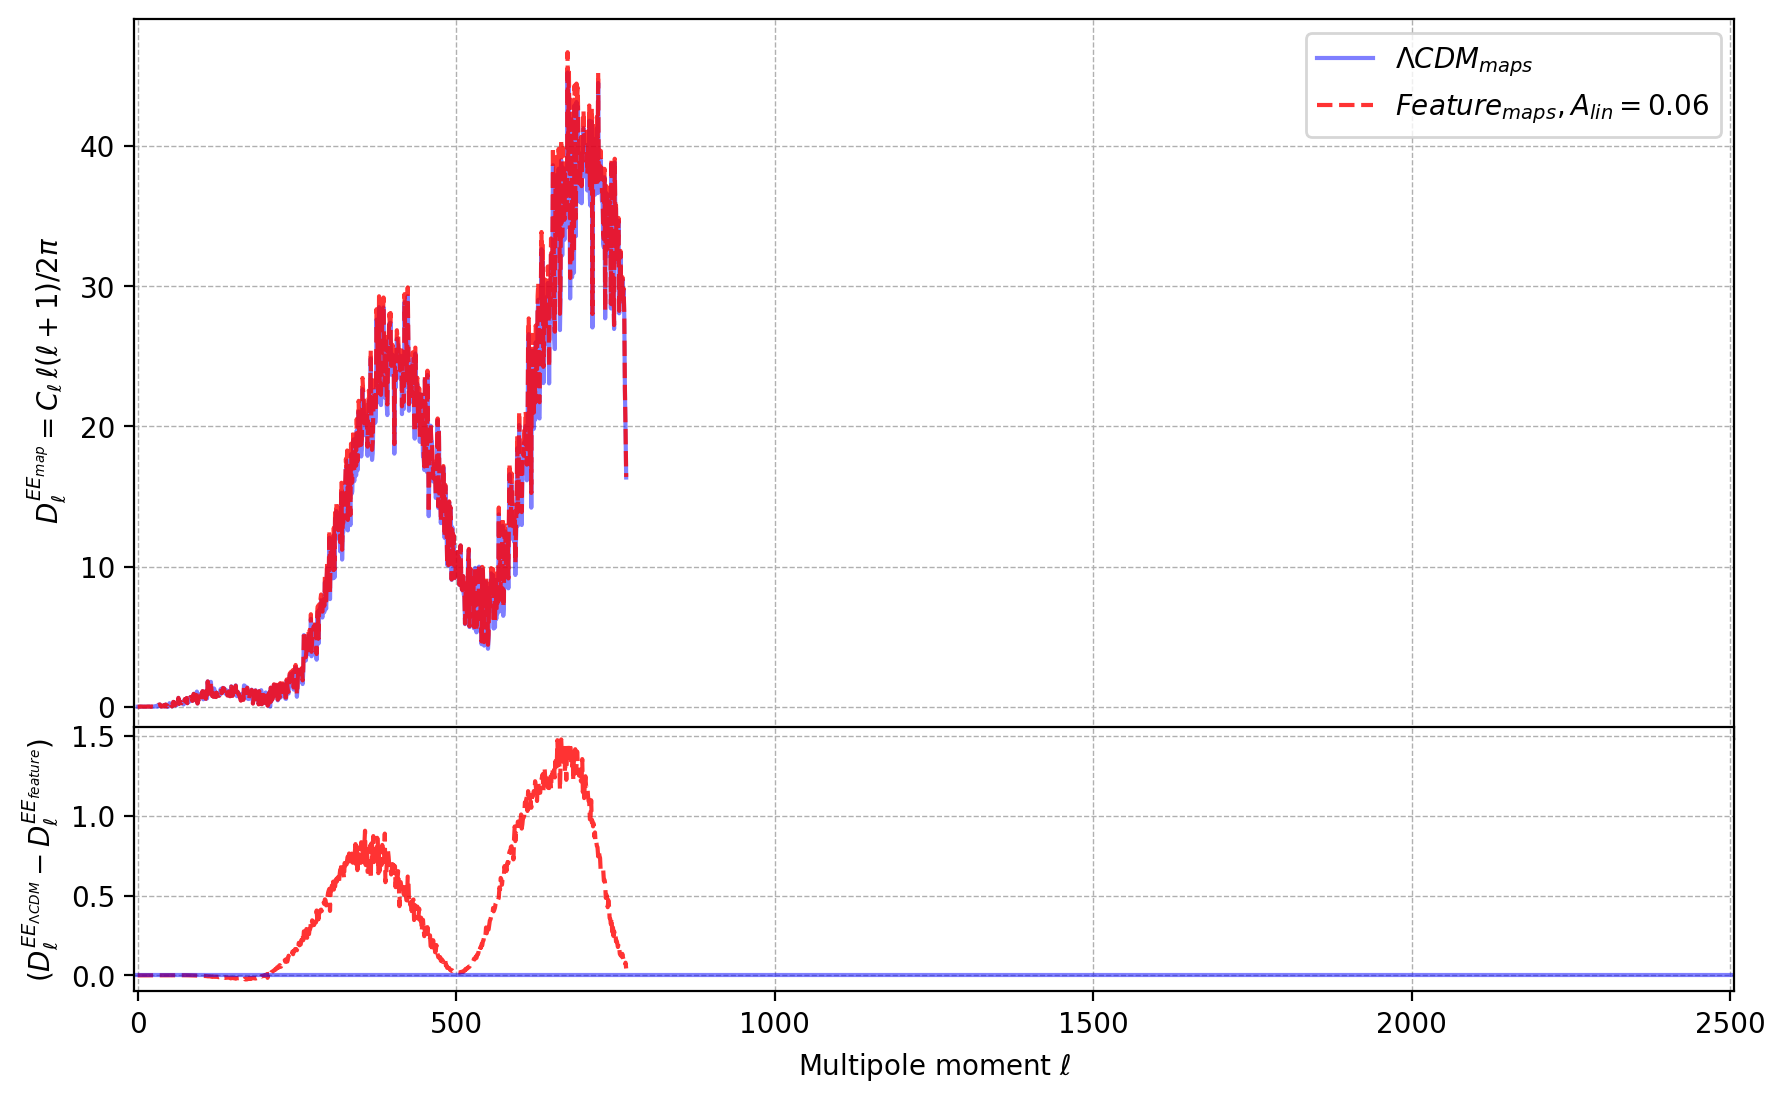

In [ ]:
lmax = len(cl_ee_map_f)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_ee_map)[:lmax], 
            label='$\Lambda CDM_{maps}$', alpha=0.5, color='blue')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_ee_map_f)[:lmax], 
            label='$Feature_{maps}, A_{lin}=0.06$', alpha=0.8, color='red', linestyle='--')
#frame1.plot(ell, Power_spectra_normal[1], 
            #label='$\Lambda CDM$', color='gray')
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{EE_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, 2507)
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()
 
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
#diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - Power_spectra_normal[1][:lmax])
#diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - Power_spectra_normal[1][:lmax])
diff1 = np.array(Dls(ell[:lmax], cl_ee_map_f)) - np.array(Dls(ell[:lmax], cl_ee_map))
#frame2.plot(ell[:lmax], diff2, color='blue', alpha=0.5)
frame2.plot(ell[:lmax], diff1, alpha=0.8, color='red', linestyle='--')
frame2.axhline(y=0, alpha=0.5, color='blue')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{EE_{\Lambda CDM}} - D_\ell^{EE_{feature}})$')
frame2.tick_params(axis='x', labelsize=10)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(plots_directory + 'Recoverable_EE_maps.png', dpi=300)

plt.show()